# Module 8: AI publications choropleth

This map shows the compound annual growth rate of scholarly AI publications by country from 2016 to 2024.

Publication data comes from the CSET Country AI Activity Metrics dataset, processed by Our World in Data. Country boundaries come from Natural Earth’s 1:10 million Admin 0 dataset.

CAGR measures the average annual rate of change. Countries with a small number of publications in 2016 can record a high CAGR from a relatively small numerical increase.

## Step 1: Load and clean the publications data

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

# road the publication data and give the columns shorter working names
df = pd.read_csv("annual-scholarly-publications-on-artificial-intelligence.csv")
df.columns = ["Entity", "Code", "Year", "n_pubs"]

# review the OWID codes before separating countries from regional totals
print(df[df["Code"].str.startswith("OWID_", na=False)][["Entity", "Code"]].drop_duplicates())

# remove the seven regional and world aggregates while retaining Kosovo.
region_codes = {"OWID_AFR", "OWID_ASI", "OWID_EUR", "OWID_NAM", "OWID_OCE", "OWID_SAM", "OWID_WRL"}
countries = df[~df["Code"].isin(region_codes) & df["Code"].notna()].copy()

# confirm the number of country entities available for analysis
print(f"Country entities: {countries['Entity'].nunique()}")

             Entity      Code
8            Africa  OWID_AFR
76             Asia  OWID_ASI
484          Europe  OWID_EUR
758          Kosovo  OWID_KOS
1055  North America  OWID_NAM
1100        Oceania  OWID_OCE
1334  South America  OWID_SAM
1577          World  OWID_WRL
Country entities: 190


## Step 2: Calculate CAGR from 2016 to 2024

CAGR represents the average annual change in publication output across the eight year period.

In [2]:
# prepare the publication counts for the first and final years
p16 = countries[countries.Year == 2016][["Entity", "Code", "n_pubs"]].rename(columns={"n_pubs": "pubs_2016"})
p24 = countries[countries.Year == 2024][["Entity", "Code", "n_pubs"]].rename(columns={"n_pubs": "pubs_2024"})

# match countries that have observations in both years
cagr = p16.merge(p24, on=["Entity", "Code"])

# calculate annual growth over eight yearly intervals
cagr["cagr"] = (cagr["pubs_2024"] / cagr["pubs_2016"]) ** (1/8) - 1

# Summarise the coverage and distribution of the calculated values
print(f"Countries with both years: {len(cagr)} (expect 146)")
print(f"CAGR range: {cagr.cagr.min():.1%} to {cagr.cagr.max():.1%}, median {cagr.cagr.median():.1%}")

# calculate the world growth rate as a reference value
w16 = df.loc[(df.Code == "OWID_WRL") & (df.Year == 2016), "n_pubs"].values[0]
w24 = df.loc[(df.Code == "OWID_WRL") & (df.Year == 2024), "n_pubs"].values[0]
GLOBAL_CAGR = (w24 / w16) ** (1/8) - 1
print(f"Global CAGR (world total): {GLOBAL_CAGR:.2%}")

Countries with both years: 146 (expect 146)
CAGR range: -8.3% to 77.0%, median 15.5%
Global CAGR (world total): 14.98%


## Step 3: Load the country boundaries

The Natural Earth GeoJSON is loaded directly from its GitHub repository. The dataset includes several unavailable `ISO_A3` values, the more complete `ADM0_A3` field is used to join the publication data to the map.

In [3]:
# Load the Natural Earth country polygons
NE_URL = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_10m_admin_0_countries_lakes.geojson"
world = gpd.read_file(NE_URL)

# inspect the boundary features that do not have a usable ISO_A3 value
broken = world[world["ISO_A3"] == "-99"][["ADMIN", "ISO_A3", "ADM0_A3"]]
print(f"Features with ISO_A3 == -99: {len(broken)}")
print(broken.head(10))

# keep the required fields and use ADM0_A3 as the country identifier
world = world[["ADMIN", "ADM0_A3", "geometry"]].rename(columns={"ADM0_A3": "iso3"})
print(f"Boundary features loaded: {len(world)}")
print(f"Unresolved (-99) codes using ADM0_A3: {(world.iso3 == '-99').sum()} (expect 0)")

Features with ISO_A3 == -99: 22
                            ADMIN ISO_A3 ADM0_A3
6    Dhekelia Sovereign Base Area    -99     ESB
20                     Somaliland    -99     SOL
21                         France    -99     FRA
52                         Norway    -99     NOR
64                         Kosovo    -99     KOS
133  US Naval Base Guantanamo Bay    -99     USG
139              Brazilian Island    -99     BRI
168               Northern Cyprus    -99     CYN
169           Cyprus No Mans Area    -99     CNM
170               Siachen Glacier    -99     KAS
Boundary features loaded: 258
Unresolved (-99) codes using ADM0_A3: 0 (expect 0)


## Step 4: Join and project the spatial data

Kosovo requires a code correction before the publication data can be matched to the Natural Earth polygons. After the merge, Antarctica is removed and the map is converted to the Equal Earth projection (`EPSG:8857`) to reduce area distortion.

In [4]:
# convert Kosovo's OWID identifier to the Natural Earth equivalent
cagr["iso3"] = cagr["Code"].replace({"OWID_KOS": "KOS"})

# attach the calculated growth values to the country polygons
merged = world.merge(cagr, on="iso3", how="left")

# confirm that every calculated country matched a boundary
print(f"Countries matched to a polygon: {merged['cagr'].notna().sum()} (expect 146)")

# remove Antarctica and use Equal Earth to reduce area distortion
merged = merged[merged["ADMIN"] != "Antarctica"].copy()
merged = merged.to_crs("EPSG:8857")

print(f"Projected CRS: {merged.crs}")

Countries matched to a polygon: 146 (expect 146)
Projected CRS: EPSG:8857


## Step 5: Divide the growth rates into six classes

Quantile classification places approximately the same number of countries in each group. The class boundaries are calculated from the data rather than selected manually.

In [5]:
# split the available growth rates into six equal-count groups
merged["cagr_class"], bin_edges = pd.qcut(merged["cagr"], 6, retbins=True)

# convert the class boundaries into readable percentage ranges
class_labels = [f"{bin_edges[i]:.1%} to {bin_edges[i+1]:.1%}" for i in range(6)]
merged["cagr_class"] = merged["cagr_class"].cat.rename_categories(class_labels)

# check how many map features belong to each class
print(merged["cagr_class"].value_counts(dropna=False).sort_index())

cagr_class
-8.3% to 7.2%      25
7.2% to 11.4%      24
11.4% to 15.5%     24
15.5% to 23.0%     24
23.0% to 30.6%     24
30.6% to 77.0%     25
NaN               111
Name: count, dtype: int64


## Step 6: Create and export the choropleth

The map uses six equal-count classes and a sequential colour palette to represent increasing publication growth. Countries without enough data to calculate CAGR are shown in grey.

High CAGR does not indicate a large volume of AI research. Some of the highest rates come from countries with very low publication counts in 2016. A visible annotation provides the starting and ending values for Uzbekistan.

Saved -> ai_cagr_choropleth.png


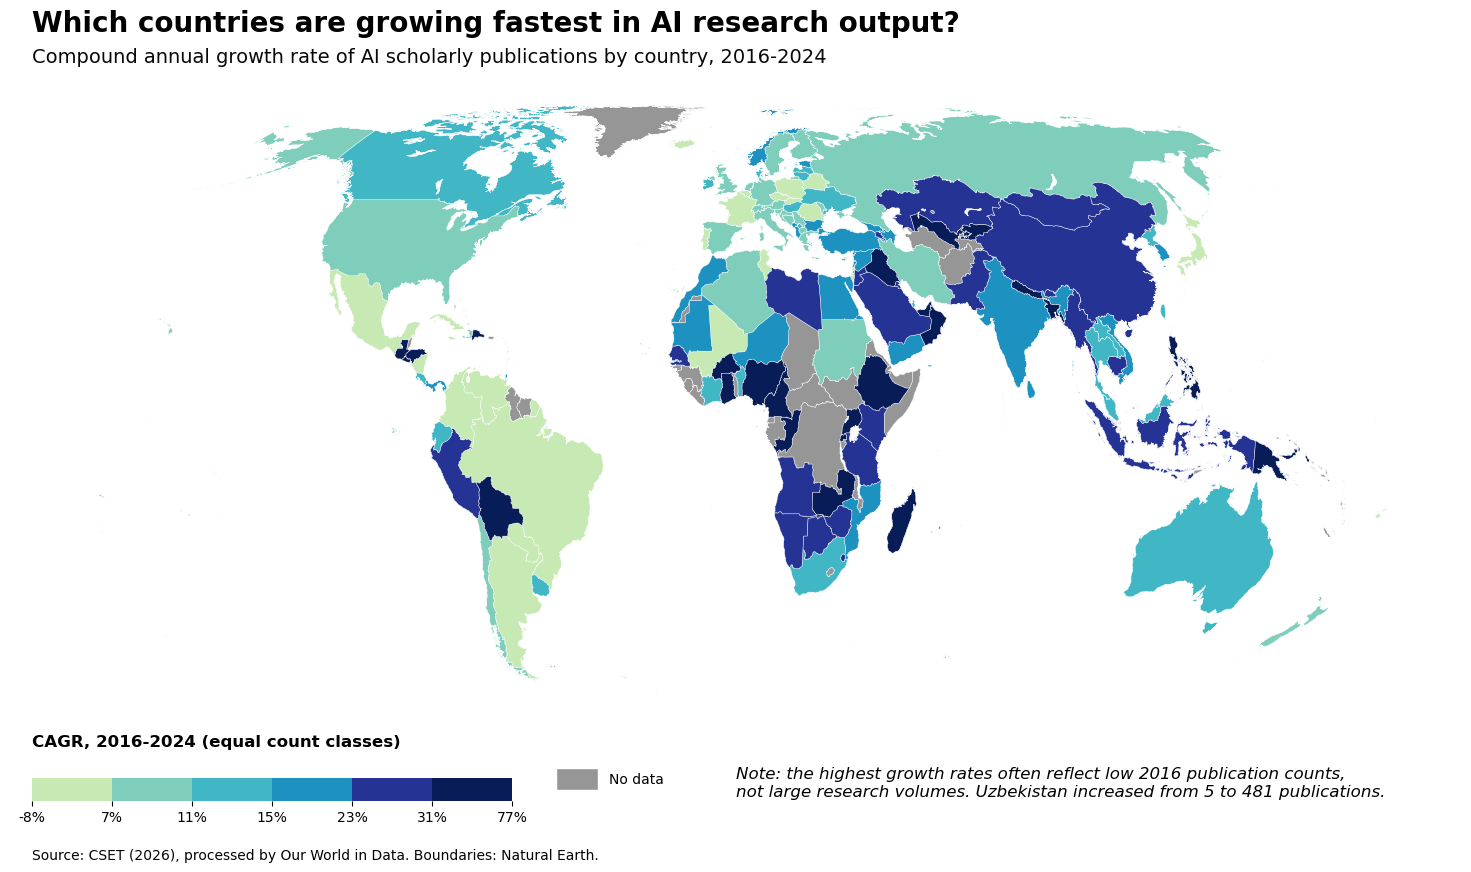

In [6]:
from matplotlib.colors import ListedColormap, BoundaryNorm

# set the colours and connect them to the calculated class boundaries
LEFT = 0.06
ylgn_colors = ["#c7e9b4", "#7fcdbb", "#41b6c4", "#1d91c0", "#253494", "#081d58"]
no_data_color = "#969696"
cmap = ListedColormap(ylgn_colors)
norm = BoundaryNorm(bin_edges, cmap.N)

# create the figure and draw countries without a calculated value first
fig, ax = plt.subplots(1, 1, figsize=(16, 9))
merged[merged["cagr_class"].isna()].plot(ax=ax, color=no_data_color, edgecolor="white", linewidth=0.3)

# add the six growth classes using the sequential palette
for label, color in zip(class_labels, ylgn_colors):
    subset = merged[merged["cagr_class"] == label]
    subset.plot(ax=ax, color=color, edgecolor="white", linewidth=0.3)

# remove the axes and preserve the Equal Earth projection
ax.set_axis_off()
ax.set_aspect("equal")
ax.set_position([0.0, 0.17, 1.0, 0.72])

# title and description
fig.text(LEFT, 0.94, "Which countries are growing fastest in AI research output?", fontsize=20, fontweight="bold", ha="left")
fig.text(LEFT, 0.905, "Compound annual growth rate of AI scholarly publications by country, 2016-2024", fontsize=14, color="#080808", ha="left")

# label and colour bar for the CAGR classes
fig.text(LEFT, 0.145, "CAGR, 2016-2024 (equal count classes)", fontsize=12, fontweight="bold", ha="left")
cax = fig.add_axes([LEFT, 0.085, 0.30, 0.025])
cb = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cax, orientation="horizontal")
cb.set_ticks(bin_edges)
cb.ax.set_xticklabels([f"{value:.0%}" for value in bin_edges], fontsize=10)
cb.outline.set_visible(False)

# show missing observations separately from the numerical colour scale
no_data_patch = Patch(facecolor=no_data_color, edgecolor="white", label="No data")
fig.legend(handles=[no_data_patch], loc="lower left", bbox_to_anchor=(0.38, 0.083), frameon=False, fontsize=10, handlelength=3, handleheight=2)

# explain why a high growth rate may come from a small starting value
fig.text(0.50, 0.105,
         "Note: the highest growth rates often reflect low 2016 publication counts,\n"
         "not large research volumes. Uzbekistan increased from 5 to 481 publications.",
         fontsize=12, color="#000000", style="italic", ha="left", va="center")

# publication and boundary sources
fig.text(LEFT, 0.02, "Source: CSET (2026), processed by Our World in Data. Boundaries: Natural Earth.", fontsize=10, color="#030303", ha="left")

# export and display the completed map
fig.savefig("ai_cagr_choropleth.png", dpi=200, bbox_inches="tight", facecolor="white")
print("Saved -> ai_cagr_choropleth.png")
plt.show()
plt.close(fig)